In [138]:
!pip install imbalanced-learn

In [139]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model

In [140]:
DATASET_PATH = "/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"

classes = ["benign","malignant","normal"]

IMG_SIZE = 128

In [141]:
images = []
labels = []

for c in classes:
    
    path = os.path.join(DATASET_PATH, c)
    
    for img in os.listdir(path):
        
        if "_mask" in img:
            continue
        
        img_path = os.path.join(path, img)
        
        image = cv2.imread(img_path)
        image = cv2.resize(image,(IMG_SIZE,IMG_SIZE))
        image = image / 255.0
        
        images.append(image)
        labels.append(c)

X = np.array(images)
y = np.array(labels)

print("Dataset shape:",X.shape)

Dataset shape: (780, 128, 128, 3)


In [142]:
le = LabelEncoder()

y = le.fit_transform(y)

print("Classes:",le.classes_)

Classes: ['benign' 'malignant' 'normal']


In [143]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [144]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:",X_train.shape)
print("Validation:",X_val.shape)
print("Test:",X_test.shape)

Train: (546, 128, 128, 3)
Validation: (117, 128, 128, 3)
Test: (117, 128, 128, 3)


In [145]:
def create_model():
    
    base_model = MobileNetV2(
        input_shape=(128,128,3),
        include_top=False,
        weights="imagenet"
    )
    
    for layer in base_model.layers:
        layer.trainable = False
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    
    x = Dense(256,activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    x = Dense(128,activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    output = Dense(3,activation="softmax")(x)
    
    model = Model(inputs=base_model.input,outputs=output)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [146]:
model_imbalanced = create_model()

history_imbalanced = model_imbalanced.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=40,
    batch_size=16
)

Epoch 1/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 177ms/step - accuracy: 0.3410 - loss: 1.5986 - val_accuracy: 0.5897 - val_loss: 0.8365
Epoch 2/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.4484 - loss: 1.4285 - val_accuracy: 0.7265 - val_loss: 0.7396
Epoch 3/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.4745 - loss: 1.2683 - val_accuracy: 0.7607 - val_loss: 0.6918
Epoch 4/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.5445 - loss: 1.1549 - val_accuracy: 0.7265 - val_loss: 0.6810
Epoch 5/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.5649 - loss: 0.9916 - val_accuracy: 0.7521 - val_loss: 0.6640
Epoch 6/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.5967 - loss: 1.0053 - val_accuracy: 0.7179 - val_loss: 0.6946
Epoch 7/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.6618 - loss: 0.8395 - val_accuracy: 0.6838 - val_loss: 0.6855
Epoch 8/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.6411 - loss: 0.8943 - val_accuracy: 0

In [147]:
y_pred = model_imbalanced.predict(X_test)

y_pred_classes = np.argmax(y_pred,axis=1)

acc1 = accuracy_score(y_test,y_pred_classes)
prec1 = precision_score(y_test,y_pred_classes,average="weighted")
rec1 = recall_score(y_test,y_pred_classes,average="weighted")
f11 = f1_score(y_test,y_pred_classes,average="weighted")

print("IMBALANCED MODEL RESULTS")

print("Accuracy:",acc1)
print("Precision:",prec1)
print("Recall:",rec1)
print("F1 Score:",f11)

print(classification_report(y_test,y_pred_classes))

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 562ms/step
IMBALANCED MODEL RESULTS
Accuracy: 0.7008547008547008
Precision: 0.727998172337795
Recall: 0.7008547008547008
F1 Score: 0.7056704687193502
              precision    recall  f1-score   support

           0       0.83      0.67      0.74        66
           1       0.55      0.71      0.62        31
           2       0.67      0.80      0.73        20

    accuracy                           0.70       117
   macro avg       0.68      0.73      0.70       117
weighted avg       0.73      0.70      0.71       117



In [148]:
X_train_flat = X_train.reshape(len(X_train),-1)

sm = SMOTE(random_state=42)

X_smote,y_smote = sm.fit_resample(X_train_flat,y_train)

print("Before SMOTE:",np.bincount(y_train))
print("After SMOTE:",np.bincount(y_smote))

Before SMOTE: [306 147  93]
After SMOTE: [306 306 306]


In [149]:
X_smote = X_smote.reshape(-1,128,128,3)

In [150]:
model_smote = create_model()

history_smote = model_smote.fit(
    X_smote,
    y_smote,
    validation_data=(X_val,y_val),
    epochs=40,
    batch_size=16
)

Epoch 1/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 147ms/step - accuracy: 0.4013 - loss: 1.6230 - val_accuracy: 0.6068 - val_loss: 0.9506
Epoch 2/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.5472 - loss: 1.1089 - val_accuracy: 0.6838 - val_loss: 0.8182
Epoch 3/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.6456 - loss: 0.8381 - val_accuracy: 0.6581 - val_loss: 0.7862
Epoch 4/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.7067 - loss: 0.7738 - val_accuracy: 0.7179 - val_loss: 0.6731
Epoch 5/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.7165 - loss: 0.7188 - val_accuracy: 0.7265 - val_loss: 0.6443
Epoch 6/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.7406 - loss: 0.6688 - val_accuracy: 0.7436 - val_loss: 0.6214
Epoch 7/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.7759 - loss: 0.5968 - val_accuracy: 0.7607 - val_loss: 0.5631
Epoch 8/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.7809 - loss: 0.5753 - val_accuracy: 0

In [151]:
y_pred = model_smote.predict(X_test)

y_pred_classes = np.argmax(y_pred,axis=1)

acc2 = accuracy_score(y_test,y_pred_classes)
prec2 = precision_score(y_test,y_pred_classes,average="weighted")
rec2 = recall_score(y_test,y_pred_classes,average="weighted")
f12 = f1_score(y_test,y_pred_classes,average="weighted")

print("SMOTE MODEL RESULTS")

print("Accuracy:",acc2)
print("Precision:",prec2)
print("Recall:",rec2)
print("F1 Score:",f12)

print(classification_report(y_test,y_pred_classes))

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 574ms/step
SMOTE MODEL RESULTS
Accuracy: 0.7692307692307693
Precision: 0.7956753597779238
Recall: 0.7692307692307693
F1 Score: 0.7742590742590743
              precision    recall  f1-score   support

           0       0.91      0.74      0.82        66
           1       0.64      0.81      0.71        31
           2       0.67      0.80      0.73        20

    accuracy                           0.77       117
   macro avg       0.74      0.78      0.75       117
weighted avg       0.80      0.77      0.77       117



In [152]:
datagen = ImageDataGenerator(
    
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    
    zoom_range=0.1,
    horizontal_flip=True,
    
    fill_mode="nearest"
)

datagen.fit(X_train)

In [153]:
model_aug = create_model()

history_aug = model_aug.fit(

    datagen.flow(X_train,y_train,batch_size=16),

    validation_data=(X_val,y_val),

    epochs=40,

    class_weight=class_weights,

    callbacks=[early_stop,reduce_lr]
)

Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.3546 - loss: 1.5097 - val_accuracy: 0.3504 - val_loss: 1.1087 - learning_rate: 1.0000e-04
Epoch 2/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.4223 - loss: 1.3900 - val_accuracy: 0.4957 - val_loss: 0.9789 - learning_rate: 1.0000e-04
Epoch 3/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.4051 - loss: 1.3325 - val_accuracy: 0.5556 - val_loss: 0.8944 - learning_rate: 1.0000e-04
Epoch 4/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.5478 - loss: 1.1663 - val_accuracy: 0.5470 - val_loss: 0.8619 - learning_rate: 1.0000e-04
Epoch 5/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.4707 - loss: 1.2163 - val_accuracy: 0.6154 - val_loss: 0.8078 - learning_rate: 1.0000e-04
Epoch 6/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.4862 - loss: 1.2307 - val_accuracy: 0.6410 - val_loss: 0.7358 - learning_rate: 1.0000e-04
Epoch 7/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - accuracy: 0.5804 - l

In [154]:
y_pred = model_aug.predict(X_test)

y_pred_classes = np.argmax(y_pred,axis=1)

acc3 = accuracy_score(y_test,y_pred_classes)
prec3 = precision_score(y_test,y_pred_classes,average="weighted")
rec3 = recall_score(y_test,y_pred_classes,average="weighted")
f13 = f1_score(y_test,y_pred_classes,average="weighted")

print("AUGMENTATION MODEL RESULTS")

print("Accuracy:",acc3)
print("Precision:",prec3)
print("Recall:",rec3)
print("F1 Score:",f13)

print(classification_report(y_test,y_pred_classes))

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 571ms/step
AUGMENTATION MODEL RESULTS
Accuracy: 0.5726495726495726
Precision: 0.6400126622348845
Recall: 0.5726495726495726
F1 Score: 0.5862745767560997
              precision    recall  f1-score   support

           0       0.80      0.55      0.65        66
           1       0.38      0.55      0.45        31
           2       0.52      0.70      0.60        20

    accuracy                           0.57       117
   macro avg       0.57      0.60      0.56       117
weighted avg       0.64      0.57      0.59       117



In [155]:
print("\nFINAL MODEL COMPARISON")

print("\nMobileNetV2 (Imbalanced)")
print("Accuracy:",acc1)
print("Precision:",prec1)
print("Recall:",rec1)
print("F1:",f11)

print("\nMobileNetV2 + SMOTE")
print("Accuracy:",acc2)
print("Precision:",prec2)
print("Recall:",rec2)
print("F1:",f12)

print("\nMobileNetV2 + Augmentation")
print("Accuracy:",acc3)
print("Precision:",prec3)
print("Recall:",rec3)
print("F1:",f13)


FINAL MODEL COMPARISON

MobileNetV2 (Imbalanced)
Accuracy: 0.7008547008547008
Precision: 0.727998172337795
Recall: 0.7008547008547008
F1: 0.7056704687193502

MobileNetV2 + SMOTE
Accuracy: 0.7692307692307693
Precision: 0.7956753597779238
Recall: 0.7692307692307693
F1: 0.7742590742590743

MobileNetV2 + Augmentation
Accuracy: 0.5726495726495726
Precision: 0.6400126622348845
Recall: 0.5726495726495726
F1: 0.5862745767560997


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


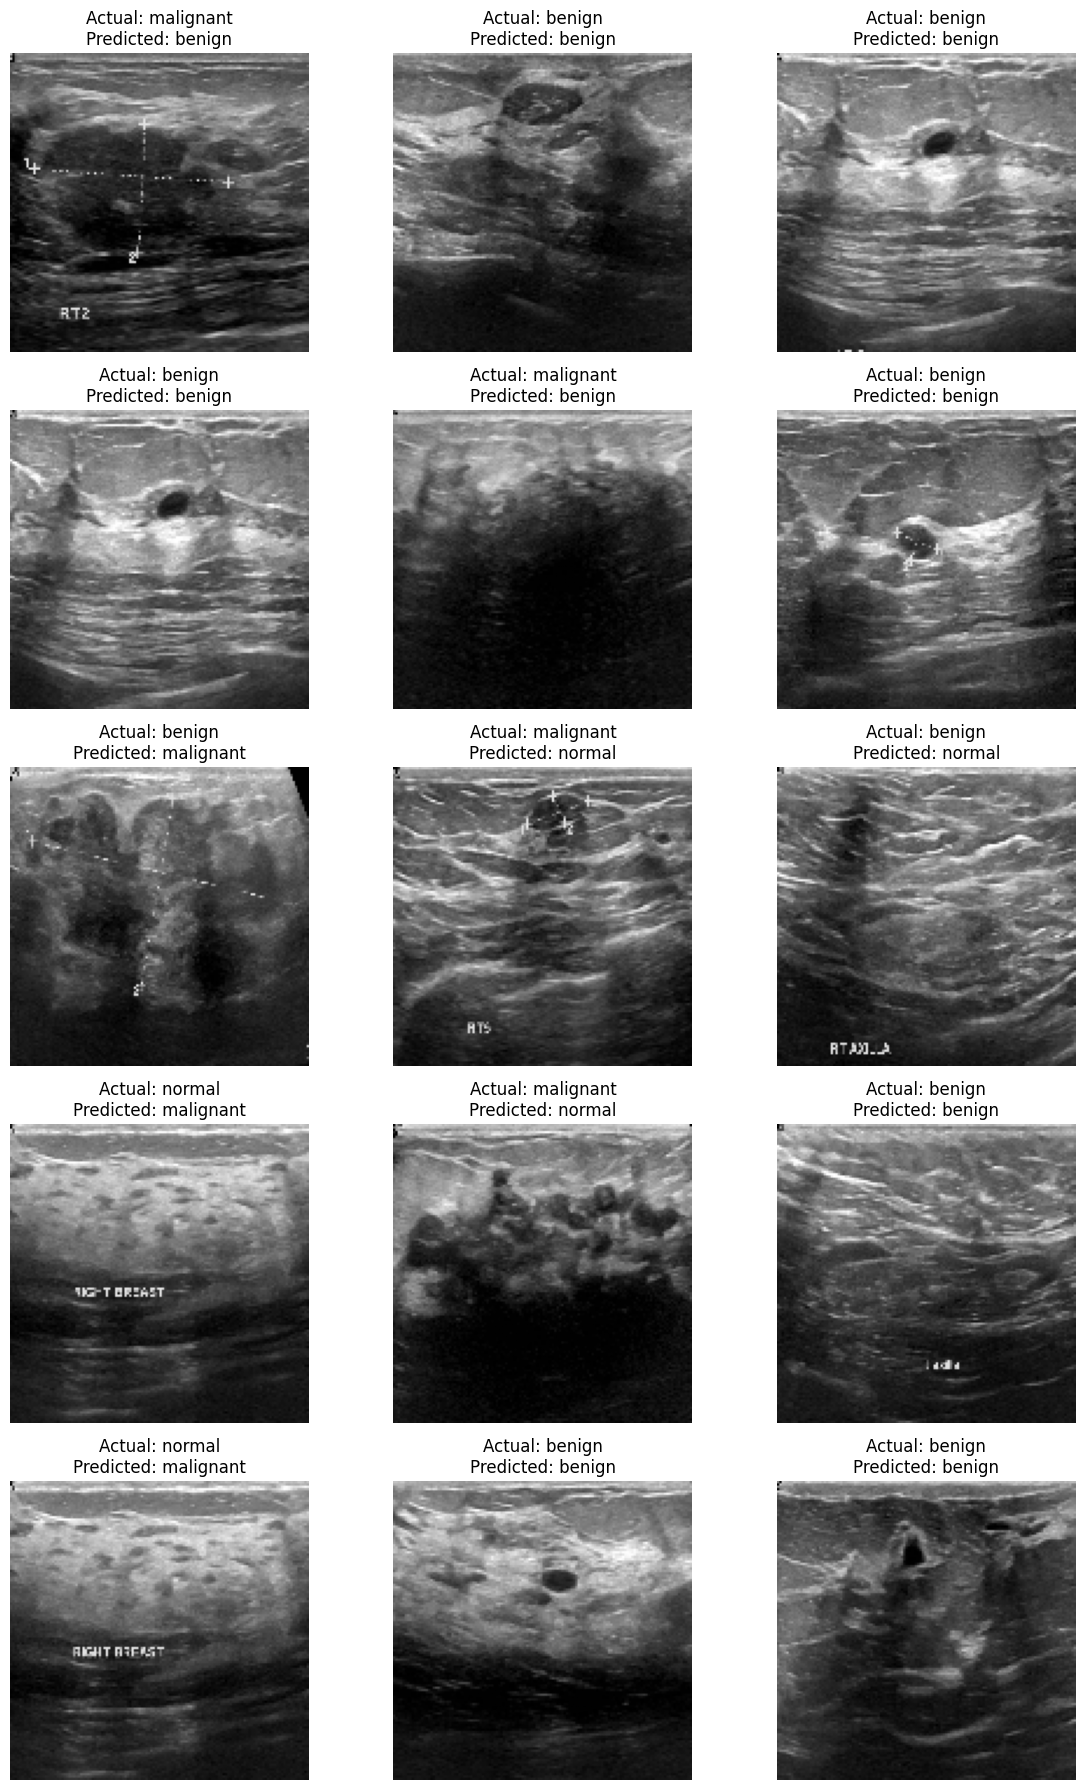

In [156]:
num_images = 15

indices = np.random.choice(len(X_test),num_images)

sample_images = X_test[indices]
sample_labels = y_test[indices]

predictions = model_aug.predict(sample_images)

pred_classes = np.argmax(predictions,axis=1)

plt.figure(figsize=(12,18))

for i in range(num_images):
    
    ax = plt.subplot(5,3,i+1)
    
    ax.axis("off")
    
    actual = le.classes_[sample_labels[i]]
    predicted = le.classes_[pred_classes[i]]
    
    ax.set_title(f"Actual: {actual}\nPredicted: {predicted}")
    
    plt.imshow(sample_images[i])

plt.tight_layout()

plt.show()